# Application 5 — Shape Differences via Spectral Analysis

The eigenvalues of the Laplace-Beltrami operator are **intrinsic shape descriptors**:
two isometric shapes share the same spectrum, and the spectrum changes smoothly with the shape.

This lets us:
- **Compare shapes** without computing any correspondence.
- **Cluster a population** by spectral distance.
- **Detect outliers** (unusual geometry) as spectral anomalies.

This notebook uses cardiac LV shapes (ACDC dataset).
Set `DATA_ROOT` below.  Alternatively, swap the loading section for any collection of meshes.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pyvista as pv
from sklearn.manifold import MDS

from geomfum.dataset.medical import AcdcDataset

pv.set_jupyter_backend("static")

## 1. Load a collection of shapes

We load left-ventricle meshes from several patients across diagnostic groups.

> **Cardiac data (ACDC)**: set `DATA_ROOT` to your ACDC directory.
>
> To use any other collection, build `shapes` and `labels` as lists of
> `(TriangleMesh, str)` pairs and skip the ACDC block.

In [2]:
# ── CONFIGURATION ────────────────────────────────────────────────────────────
DATA_ROOT = "../../../../ACDC/database/training/"  # TODO: set your ACDC data path
GROUPS = ["NOR", "DCM", "HCM", "RVA"]  # diagnostic groups
N_PER_GROUP = 5  # shapes to load per group
K_SPECTRUM = 100  # number of eigenvalues
# ─────────────────────────────────────────────────────────────────────────────
shapes = []
labels = []
for group in GROUPS:
    ds = AcdcDataset(root=DATA_ROOT, groups=[group])  # groups must be a list
    for idx, (mesh_ed, mesh_es, meta) in enumerate(ds):  # unpack the tuple
        if idx >= N_PER_GROUP:
            break
        mesh_ed.vertices -= mesh_ed.vertices.mean(0)
        shapes.append(mesh_ed)  # use end-diastole mesh (or mesh_es for end-systole)
        labels.append(group)

print(f"Loaded {len(shapes)} shapes across {len(GROUPS)} groups")

Loaded 15 shapes across 4 groups


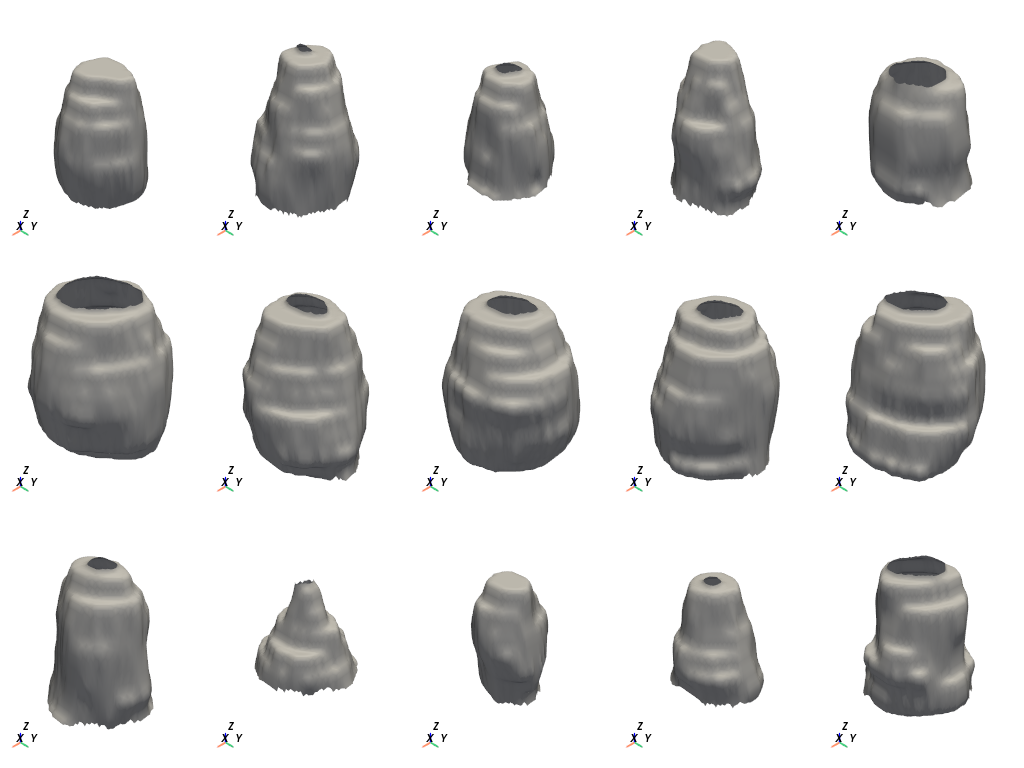

In [3]:
import sys
from pathlib import Path

import geomfum

notebooks_dir = Path(geomfum.__file__).resolve().parents[1] / "notebooks"
notebooks_dir_str = str(notebooks_dir)
if notebooks_dir_str not in sys.path:
    sys.path.insert(0, notebooks_dir_str)

from plot_utils import show_multiple_meshes  # noqa: E402

show_multiple_meshes(
    vertices_list=[m.vertices for m in shapes],
    faces_list=[m.faces for m in shapes],
    n_cols=5,
)

## 2. Compute LBO spectrum for each shape

We keep only the eigenvalues (no eigenvectors needed for spectral distance).

In [4]:
spectra = []
for i, mesh in enumerate(shapes):
    mesh.laplacian.find_spectrum(spectrum_size=K_SPECTRUM, set_as_basis=False)
    evals = np.array(mesh.basis.vals)  # (K,)
    spectra.append(evals)
    if (i + 1) % 5 == 0:
        print(f"  {i + 1}/{len(shapes)} done")

spectra = np.stack(spectra)  # (n_shapes, K)
print(f"Spectra matrix: {spectra.shape}")

  5/15 done
  10/15 done
  15/15 done
Spectra matrix: (15, 100)


## 3. Compare eigenvalue curves

Shapes in the same group should have similar eigenvalue profiles.
Deviations reveal geometric differences.

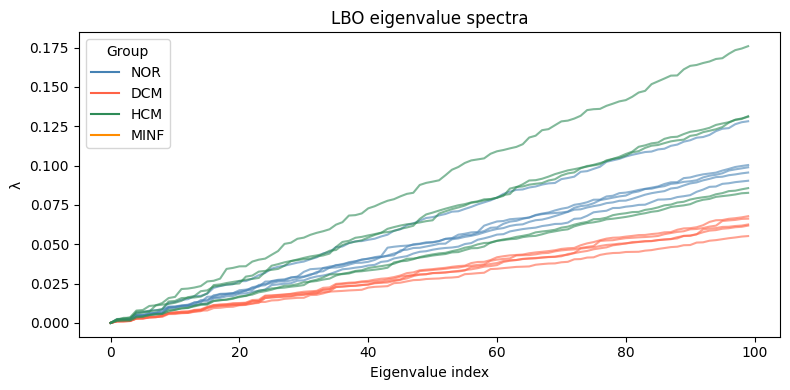

In [5]:
group_colors = {
    "NOR": "steelblue",
    "DCM": "tomato",
    "HCM": "seagreen",
    "MINF": "darkorange",
}

fig, ax = plt.subplots(figsize=(8, 4))
for i, (evals, label) in enumerate(zip(spectra, labels)):
    ax.plot(
        evals,
        color=group_colors.get(label, "gray"),
        alpha=0.6,
        label=label if labels[:i].count(label) == 0 else "",
    )

handles = [plt.Line2D([0], [0], color=c, label=g) for g, c in group_colors.items()]
ax.legend(handles=handles, title="Group")
ax.set_xlabel("Eigenvalue index")
ax.set_ylabel("λ")
ax.set_title("LBO eigenvalue spectra")
plt.tight_layout()
plt.show()

## 4. Pairwise spectral distance matrix

Spectral distance = L2 distance between normalised eigenvalue vectors.
It is scale-invariant (we normalise by the first non-zero eigenvalue).

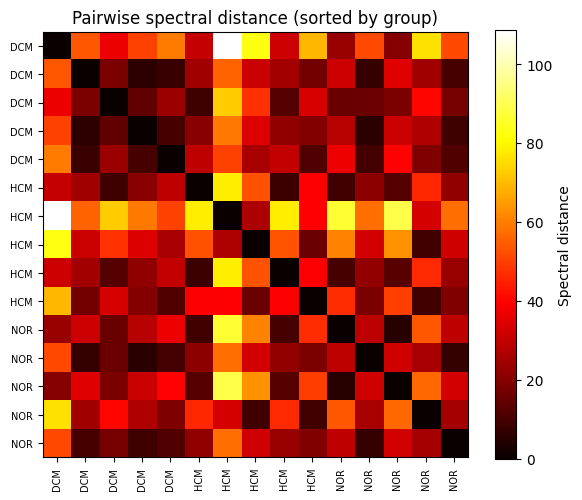

In [6]:
# Normalise each spectrum by its second eigenvalue (first non-trivial)
spectra_norm = spectra / spectra[:, 1:2]

n = len(shapes)
dist_matrix = np.zeros((n, n))
for i in range(n):
    for j in range(i + 1, n):
        d = np.linalg.norm(spectra_norm[i] - spectra_norm[j])
        dist_matrix[i, j] = dist_matrix[j, i] = d

# Sort by group for a cleaner matrix display
order = np.argsort(labels)
dm_sorted = dist_matrix[np.ix_(order, order)]
labels_sorted = [labels[i] for i in order]

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(dm_sorted, cmap="hot")
plt.colorbar(im, ax=ax, label="Spectral distance")
ticks = np.arange(n)
ax.set_xticks(ticks)
ax.set_yticks(ticks)
ax.set_xticklabels(labels_sorted, rotation=90, fontsize=7)
ax.set_yticklabels(labels_sorted, fontsize=7)
ax.set_title("Pairwise spectral distance (sorted by group)")
plt.tight_layout()
plt.show()

## 5. 2-D embedding (MDS)

Multi-dimensional scaling maps the distance matrix to 2-D.
Well-separated clusters indicate spectrally distinct shape classes.

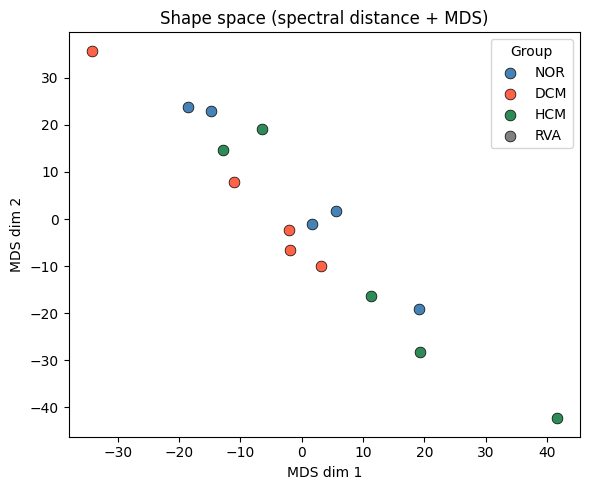

In [7]:
embedding = MDS(n_components=2, dissimilarity="precomputed", random_state=0)
coords = embedding.fit_transform(dist_matrix)  # (n_shapes, 2)

fig, ax = plt.subplots(figsize=(6, 5))
for group in GROUPS:
    idx = [i for i, l in enumerate(labels) if l == group]
    ax.scatter(
        coords[idx, 0],
        coords[idx, 1],
        color=group_colors.get(group, "gray"),
        label=group,
        s=60,
        edgecolors="k",
        linewidths=0.5,
    )

ax.legend(title="Group")
ax.set_xlabel("MDS dim 1")
ax.set_ylabel("MDS dim 2")
ax.set_title("Shape space (spectral distance + MDS)")
plt.tight_layout()
plt.show()

Clusters in the MDS plot correspond to groups with geometrically similar LV shapes.
Outliers indicate unusual morphology that is worth inspecting manually.